In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
np.__version__

'2.3.5'

In [3]:
df = pd.read_csv(r"C:\Users\nandi\Documents\ML_CO2_ER\data\df_merged.csv")
ip_data = pd.read_csv(r"C:\Users\nandi\Documents\ML_CO2_ER\data\Data_computed_properties\filtered_ip.csv")
ip_data.dropna(inplace=True)
ip_data.rename(columns={'solvent ID': 'solvent_ID', 'IP_0-1': 'IP_values'}, inplace=True)

In [4]:
ip_data['solvent_ID'].nunique()
ip_data['smiles'].nunique()

3083

In [5]:
def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None
    return None

In [6]:
ip_data['smiles_can'] = ip_data['smiles'].apply(canonicalize_smiles)
df['smiles_can'] = df['smiles'].apply(canonicalize_smiles)

[13:57:15] Explicit valence for atom # 4 N, 4, is greater than permitted
[13:57:15] Explicit valence for atom # 1 N, 4, is greater than permitted
[13:57:15] Explicit valence for atom # 4 N, 4, is greater than permitted
[13:57:15] WARNING: not removing hydrogen atom without neighbors
[13:57:15] Explicit valence for atom # 4 N, 4, is greater than permitted
[13:57:15] Explicit valence for atom # 7 N, 4, is greater than permitted
[13:57:15] Explicit valence for atom # 3 N, 4, is greater than permitted
[13:57:15] Explicit valence for atom # 4 N, 4, is greater than permitted


In [7]:
ip_data['smiles_can'].dropna(inplace=True)
df['smiles_can'].dropna(inplace=True)

In [8]:
df = pd.merge(ip_data, df, on='smiles_can', how='inner', suffixes=('', '_y'))

In [9]:
df.head()

,solvent_ID,smiles,IP_values,smiles_can,solvent_ID_y,smiles_y,Binding_Energy_eV,solubility_CO2 [mol/L],viscosity [Pa s],nAcid,...,lumo_eV,homo_lumo_gap_eV,polarizability_ang3,min_partial_charge,max_partial_charge,min_abs_partial_charge,max_abs_partial_charge,vib_freq_min_cm1,vib_freq_max_cm1,vib_freq_count
0,zinc_1345620175,C[C@H](N[C@@H]1CCCC[C@H]1F)[C@@H](C)O,0.724053,C[C@H](N[C@@H]1CCCC[C@H]1F)[C@@H](C)O,zinc_1345620175,C[C@H]([C@@H](N[C@@H]1CCCC[C@H]1F)C)O,-0.214742,0.079341,0.150835,0.0,...,-4.168789,162.745678,849.696107,-0.819411,0.453256,0.172385,0.819411,51.2361,3727.7322,93.0
1,zinc_674912368,COC[C@H](C)N1C[C@@H]2CCC[C@H]2C1,0.255187,COC[C@H](C)N1C[C@@H]2CCC[C@H]2C1,zinc_674912368,COC[C@@H](N1C[C@H]2[C@H](C1)CCC2)C,-0.214342,0.094735,0.011400,0.0,...,1.917791,150.631754,924.031534,-0.779818,0.232699,0.000737,0.779818,35.7164,3128.8524,96.0
2,zinc_644654185,CC[C@@H](O)CNCC(C)(F)F,1.070564,CC[C@@H](O)CNCC(C)(F)F,zinc_644654185,CC[C@H](CNCC(F)(F)C)O,-0.212998,0.096515,0.022542,0.0,...,-1.747485,177.540066,666.772267,-0.824957,0.633432,0.059057,0.824957,43.3486,3716.1399,72.0
3,zinc_132906027,CC[C@@H](NCCOCC(C)C)C1CC1,0.763281,CC[C@@H](NCCOCC(C)C)C1CC1,zinc_132906027,CC[C@H](C1CC1)NCCOCC(C)C,-0.215950,0.079947,0.004861,0.0,...,2.125120,166.188816,1044.297027,-0.927964,0.380666,0.011509,0.927964,22.3711,3510.5041,111.0
4,zinc_156549661,C[C@H](O)CN1CCC[C@H]1C,0.313528,C[C@H](O)CN1CCC[C@H]1C,zinc_156549661,C[C@@H](CN1CCC[C@H]1C)O,-0.198320,0.088578,0.081929,0.0,...,0.436871,157.318107,709.790668,-0.610850,0.449006,0.051486,0.610850,43.4119,3722.5285,75.0


In [10]:
df.drop("solvent_ID_y", inplace=True, axis=1)

df.drop("smiles_y", inplace=True, axis=1)

In [11]:
print(df['solvent_ID'].nunique())
print(df['smiles'].nunique())

2895
2879


In [12]:
df_clean = df.dropna(subset=['IP_values']).copy()

In [13]:
print(f"Dataset merged! New shape: {df_clean.shape}")

Dataset merged! New shape: (2921, 1422)


In [14]:
# Define Features (X) and Target (y)
target_col = 'IP_values'
exclude_cols = ['smiles', 'smiles_can', 'solvent_ID', 'IP_values', 'scaffold', 'solubility_CO2 [mol/L]', 'viscosity [Pa s]', 'Binding_Energy_eV']
X_cols = [c for c in df_clean.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_clean[c])]

In [15]:
X = df_clean[X_cols]
y = df_clean[target_col]

In [16]:
# Create Scaffold (OOD) Split

def get_scaffold(s):
    try:
        mol = Chem.MolFromSmiles(s)
        if mol: return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    except: return None
    return None

In [17]:
df_clean['scaffold'] = df_clean['smiles_can'].apply(get_scaffold)
scaffold_counts = df_clean['scaffold'].value_counts()
unique_scaffolds = scaffold_counts.index.tolist()

In [18]:
unique_scaffolds

['',
 'C1CC1',
 'C1CCNC1',
 'C1CCC1',
 'C1CCNCC1',
 'C1CNC1',
 'C1CCCC1',
 'C1COCCN1',
 'C1CCOC1',
 'C1COC1',
 'C1CCCCC1',
 'C1CCOCC1',
 'C1CO1',
 'C1COCO1',
 'C1CCCNCC1',
 'O=C1OCCO1',
 'C1CN1',
 'C1CN(CC2CC2)CCO1',
 'O=C1OCCCO1',
 'C1NCC2CC12',
 'C1OCC2OC12',
 'C1CN(CC2CC2)C1',
 'C1CCCCCC1',
 'C1CC1CC1CC1',
 'C1=CCCC1',
 'C1CC1NC1COC1',
 'C1CCCNCCC1',
 'C1CCN(CC2CC2)C1',
 'C1COCOC1',
 'O=C1CCCO1',
 'O=C1COCO1',
 'C1CC(NCC2CC2)C1',
 'C1CCC(N2CCOCC2)C1',
 'C1CNCCN1',
 'C1CC2OC2C1',
 'C1CC(CN2CCOCC2)C1',
 'C=C1COC(=O)O1',
 'C1CC2CC2CN1',
 'C1CC(C2CC2)CN1',
 'C1CC2CCC1N2',
 'C1CCN(CC2CO2)CC1',
 'C1CC(CNC2CCC2)C1',
 'C=C1CCNCC1',
 'C1CC(NC2CCC2)C1',
 'O=C1CCOC1',
 'C1CN2CCC1C2',
 'C1CCN(CCOC2CC2)C1',
 'C=C1CCOC1',
 'C1CCN(CCC2CC2)C1',
 'C1CCCCNCCC1',
 'C1CC12CNC2',
 'C1CCCCCCC1',
 'C1CC1C1CO1',
 'C1CC(NC2CCOC2)C1',
 'C1CCN(CC2CC2)CC1',
 'C1CCC(NC2CC2)C1',
 'C1CCC2NCC2C1',
 'C1CCC(N2CCOCC2)CC1',
 'C1CCN(C2CCCC2)CC1',
 'C1OC2OC12',
 'C1CC(CN2CCCC2)C1',
 'C1CC2(C1)CO2',
 'C1CC(NCC2CC2)CO1',


In [19]:
len(unique_scaffolds)

139

In [20]:
# Put common scaffolds in Train (80%), rare/distinct ones in Test (20%)
train_scaffolds = []
train_count = 0
total_count = len(df_clean)

for sc in unique_scaffolds:
    if train_count + scaffold_counts[sc] <= total_count * 0.8:
        train_scaffolds.append(sc)
        train_count += scaffold_counts[sc]

train_mask = df_clean['scaffold'].isin(train_scaffolds)
test_mask = ~train_mask

In [21]:
len(train_mask[train_mask == True])

2336

In [22]:
len(test_mask[test_mask == True])

585

In [23]:
X_train_ood, X_test_ood = X[train_mask], X[test_mask]
y_train_ood, y_test_ood = y[train_mask], y[test_mask]

# Create Random Split for comparison
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),       # Handle NaNs strictly
    ('var_thresh', VarianceThreshold(threshold=0)),      # Drop constant cols
    ('scaler', StandardScaler()),                        # Normalize (Optional for RF, but good for Feature Sel)
    ('selector', SelectKBest(f_regression, k=20)),       # Strict feature selection
    ('model', rf_model)                                  # Your optimized RF
])

In [25]:
# OOD Split Performance
print("Training OOD Split...")
pipeline.fit(X_train_ood, y_train_ood)
y_pred_ood = pipeline.predict(X_test_ood)
stats_ood = (r2_score(y_test_ood, y_pred_ood), mean_absolute_error(y_test_ood, y_pred_ood))

Training OOD Split...


In [26]:
stats_ood

(0.8830191671944208, 0.18677475252712214)

In [27]:
print("Training Random Split...")
pipeline.fit(X_train_rand, y_train_rand)
y_pred_rand = pipeline.predict(X_test_rand)
stats_rand = (r2_score(y_test_rand, y_pred_rand), mean_absolute_error(y_test_rand, y_pred_rand))

Training Random Split...


In [28]:
stats_rand

(0.9169937027793276, 0.11142744675466698)

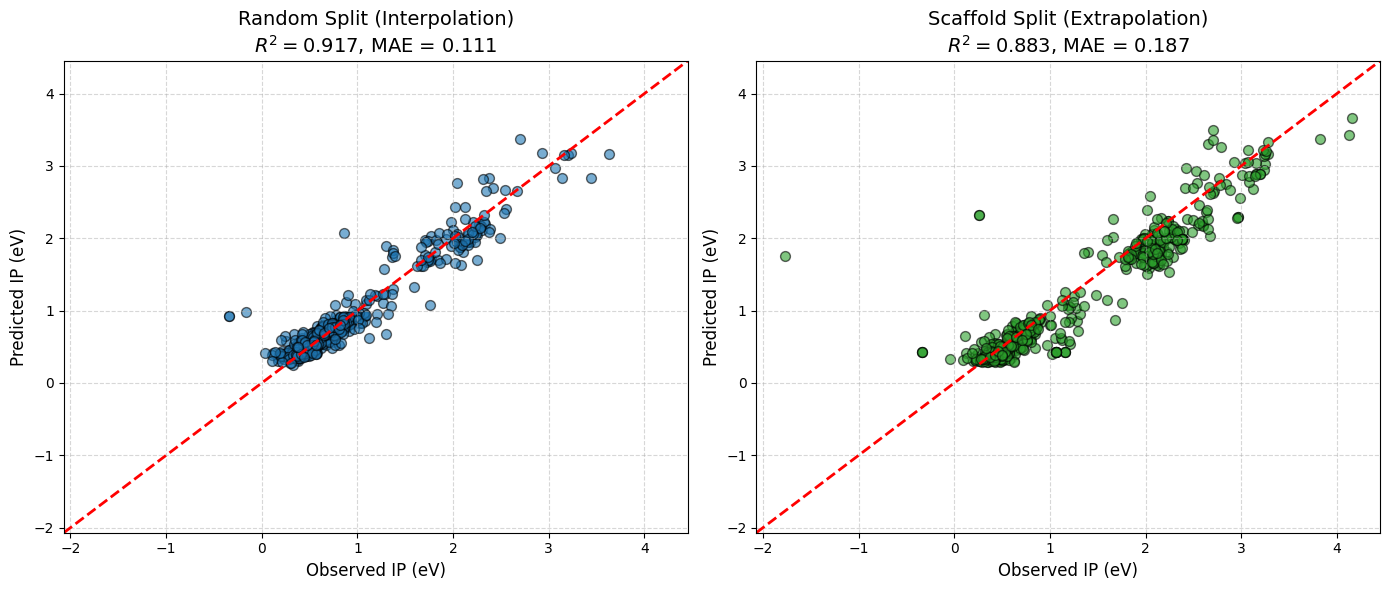

OOD R2: 0.883
Random R2: 0.917


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Unified axis limits
all_vals = np.concatenate([y_test_rand, y_pred_rand, y_test_ood, y_pred_ood])
min_val, max_val = np.min(all_vals), np.max(all_vals)
pad = (max_val - min_val) * 0.05
lims = [min_val - pad, max_val + pad]

# Plot Random Split
axes[0].scatter(y_test_rand, y_pred_rand, alpha=0.6, c='#1f77b4', edgecolors='k', s=50)
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f"Random Split (Interpolation)\n$R^2 = {stats_rand[0]:.3f}$, MAE = {stats_rand[1]:.3f}", fontsize=14)
axes[0].set_xlabel("Observed IP (eV)", fontsize=12)
axes[0].set_ylabel("Predicted IP (eV)", fontsize=12)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot OOD Split
axes[1].scatter(y_test_ood, y_pred_ood, alpha=0.6, c='#2ca02c', edgecolors='k', s=50)
axes[1].plot(lims, lims, 'r--', lw=2)
axes[1].set_title(f"Scaffold Split (Extrapolation)\n$R^2 = {stats_ood[0]:.3f}$, MAE = {stats_ood[1]:.3f}", fontsize=14)
axes[1].set_xlabel("Observed IP (eV)", fontsize=12)
axes[1].set_ylabel("Predicted IP (eV)", fontsize=12)
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('RF_OOD_Validation.png', dpi=300)
plt.show()

print(f"OOD R2: {stats_ood[0]:.3f}")
print(f"Random R2: {stats_rand[0]:.3f}")

C:\Users\nandi\AppData\Local\Temp\ipykernel_8808\844745952.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 5], [0, 5], 'k--', linewidth=1, color='black')
C:\Users\nandi\AppData\Local\Temp\ipykernel_8808\844745952.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


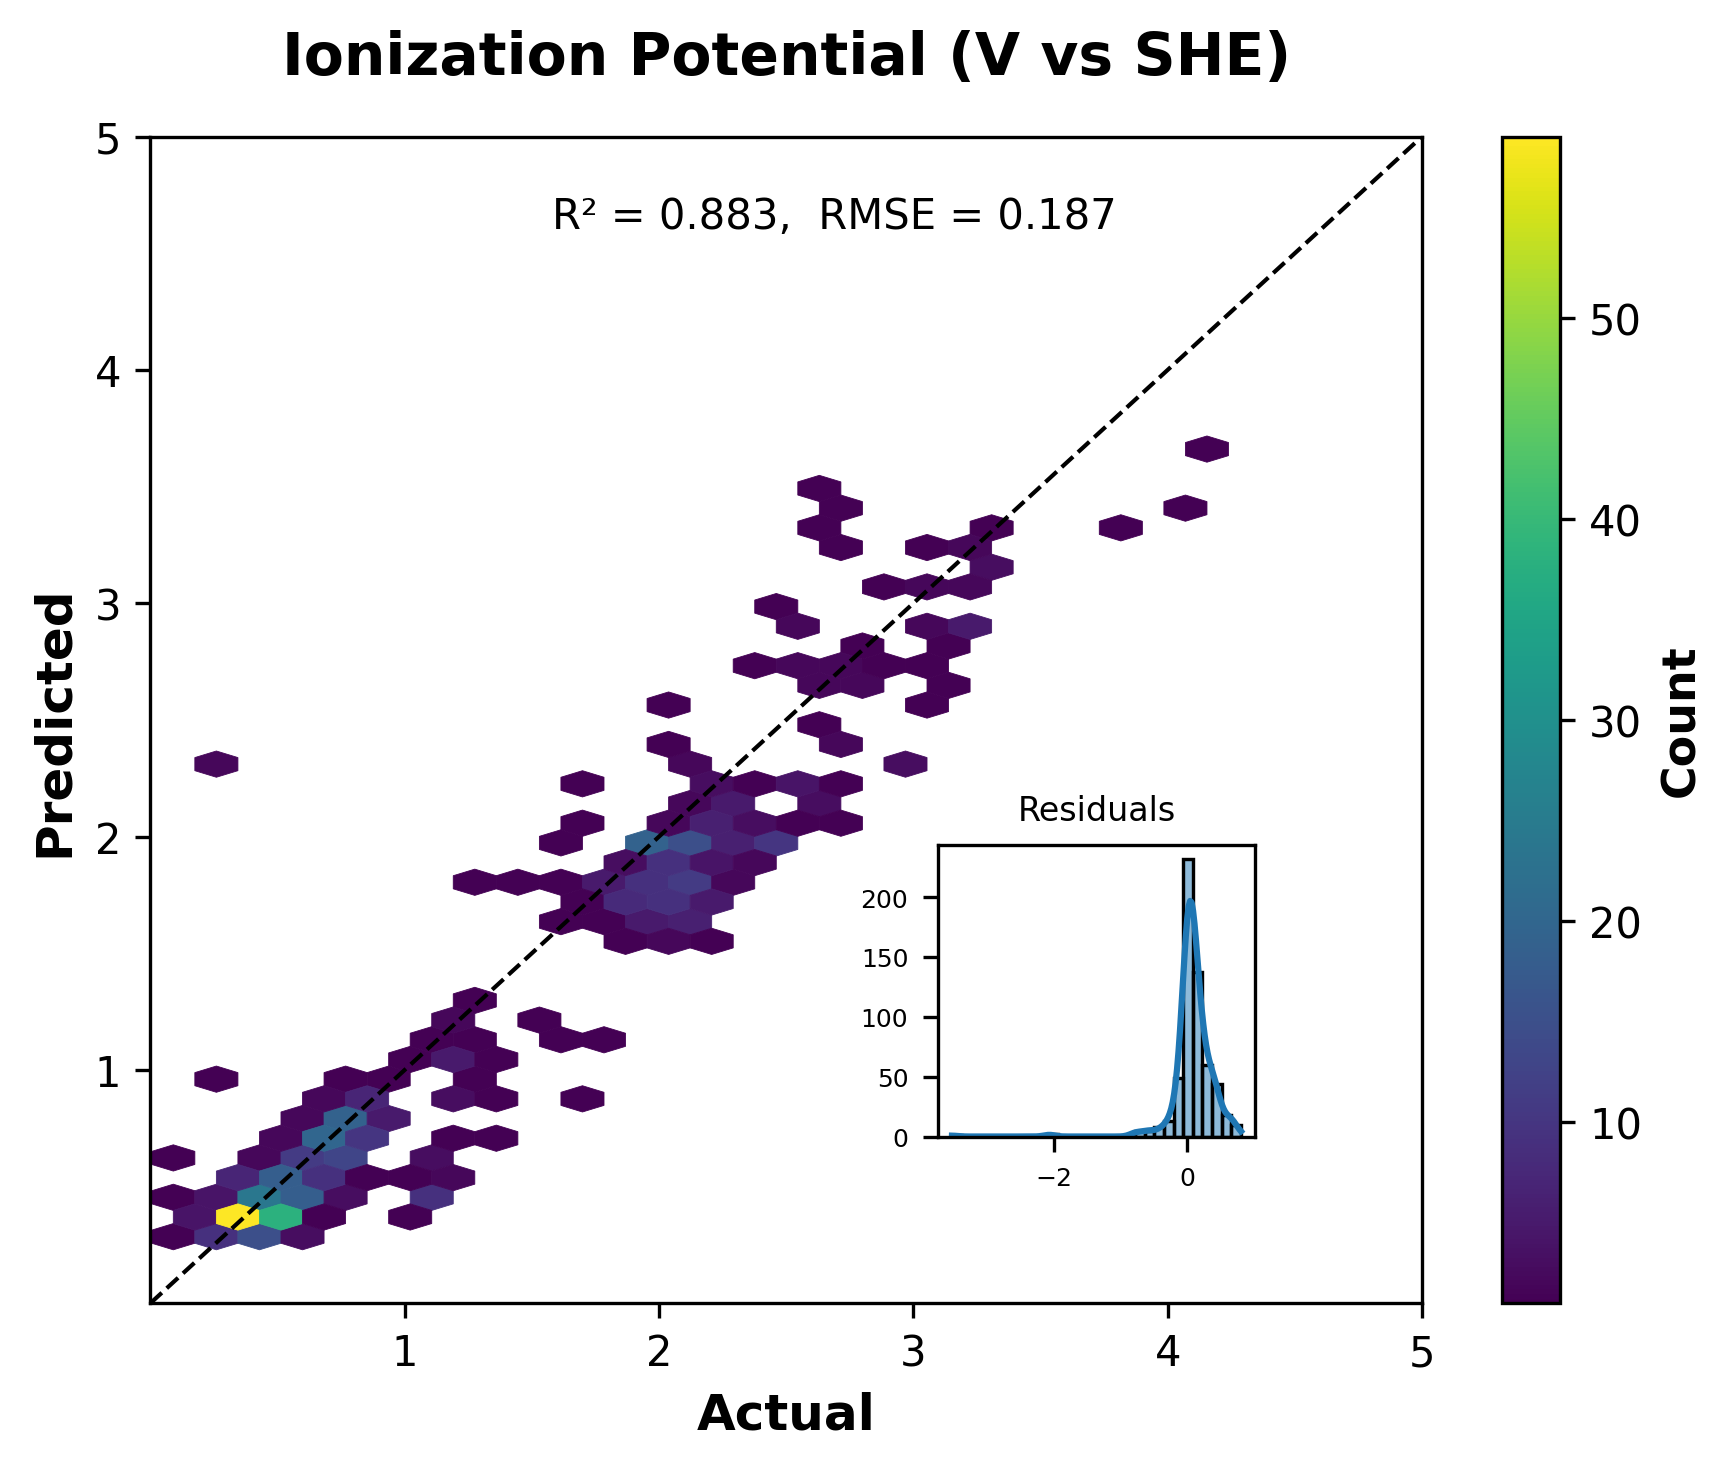

In [45]:
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Use point density plot (e.g. hexbin in matplotlib) instead of scatter plot for above to show the distribution information for the overlapped data points along with labeling the axes and adding a diagonal reference line.
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# Create hexbin plot with better visibility
hb = ax.hexbin(y_test_ood, y_pred_ood, gridsize=35, cmap='viridis', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Diagonal reference line
ax.plot([0, 5], [0, 5], 'k--', linewidth=1, color='black')
# ax.plot([y_test_ood.min(), y_test_ood.max()], [y_test_ood.min(), y_test_ood.max()], 'k--', linewidth=1, color='black')

# remove 0 tick mark from x and y axis
ax.set_xticks([tick for tick in ax.get_xticks() if tick != 0])
ax.set_yticks([tick for tick in ax.get_yticks() if tick != 0])

# adjust x and y axis range (max 5 - as original scatter plot)
# diagonal line -make sure it spans the whole plot range.
# ax.set_xlim(left=y_test_ood.min(), right=5)
# ax.set_ylim(bottom=y_test_ood.min(), top=5)
ax.set_xlim(left=0, right=5)
ax.set_ylim(bottom=0, top=5)

x_center = (y_test_ood.min() + y_test_ood.max()) / 2

# Title and axes labels
ax.set_title(f"Ionization Potential (V vs SHE)", 
             fontsize=14, fontweight='bold', pad=15)
# this should be inside the plot
y_top = ax.get_ylim()[1] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
ax.text(x_center + 1.5, y_top, f"R² = {stats_ood[0]:.3f},  RMSE = {stats_ood[1]:.3f}",
        fontsize=10, ha='center', va='top')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
# ➤ Inset residual plot
residuals = y_test_ood - y_pred_ood
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=4)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)
# ax.legend(fontsize=11, loc='upper left')
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("IP_hexbin_density_plot_rf_ood.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\nandi\AppData\Local\Temp\ipykernel_8808\1498983327.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([0, 5], [0, 5], 'k--', linewidth=1, color='black')
C:\Users\nandi\AppData\Local\Temp\ipykernel_8808\1498983327.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


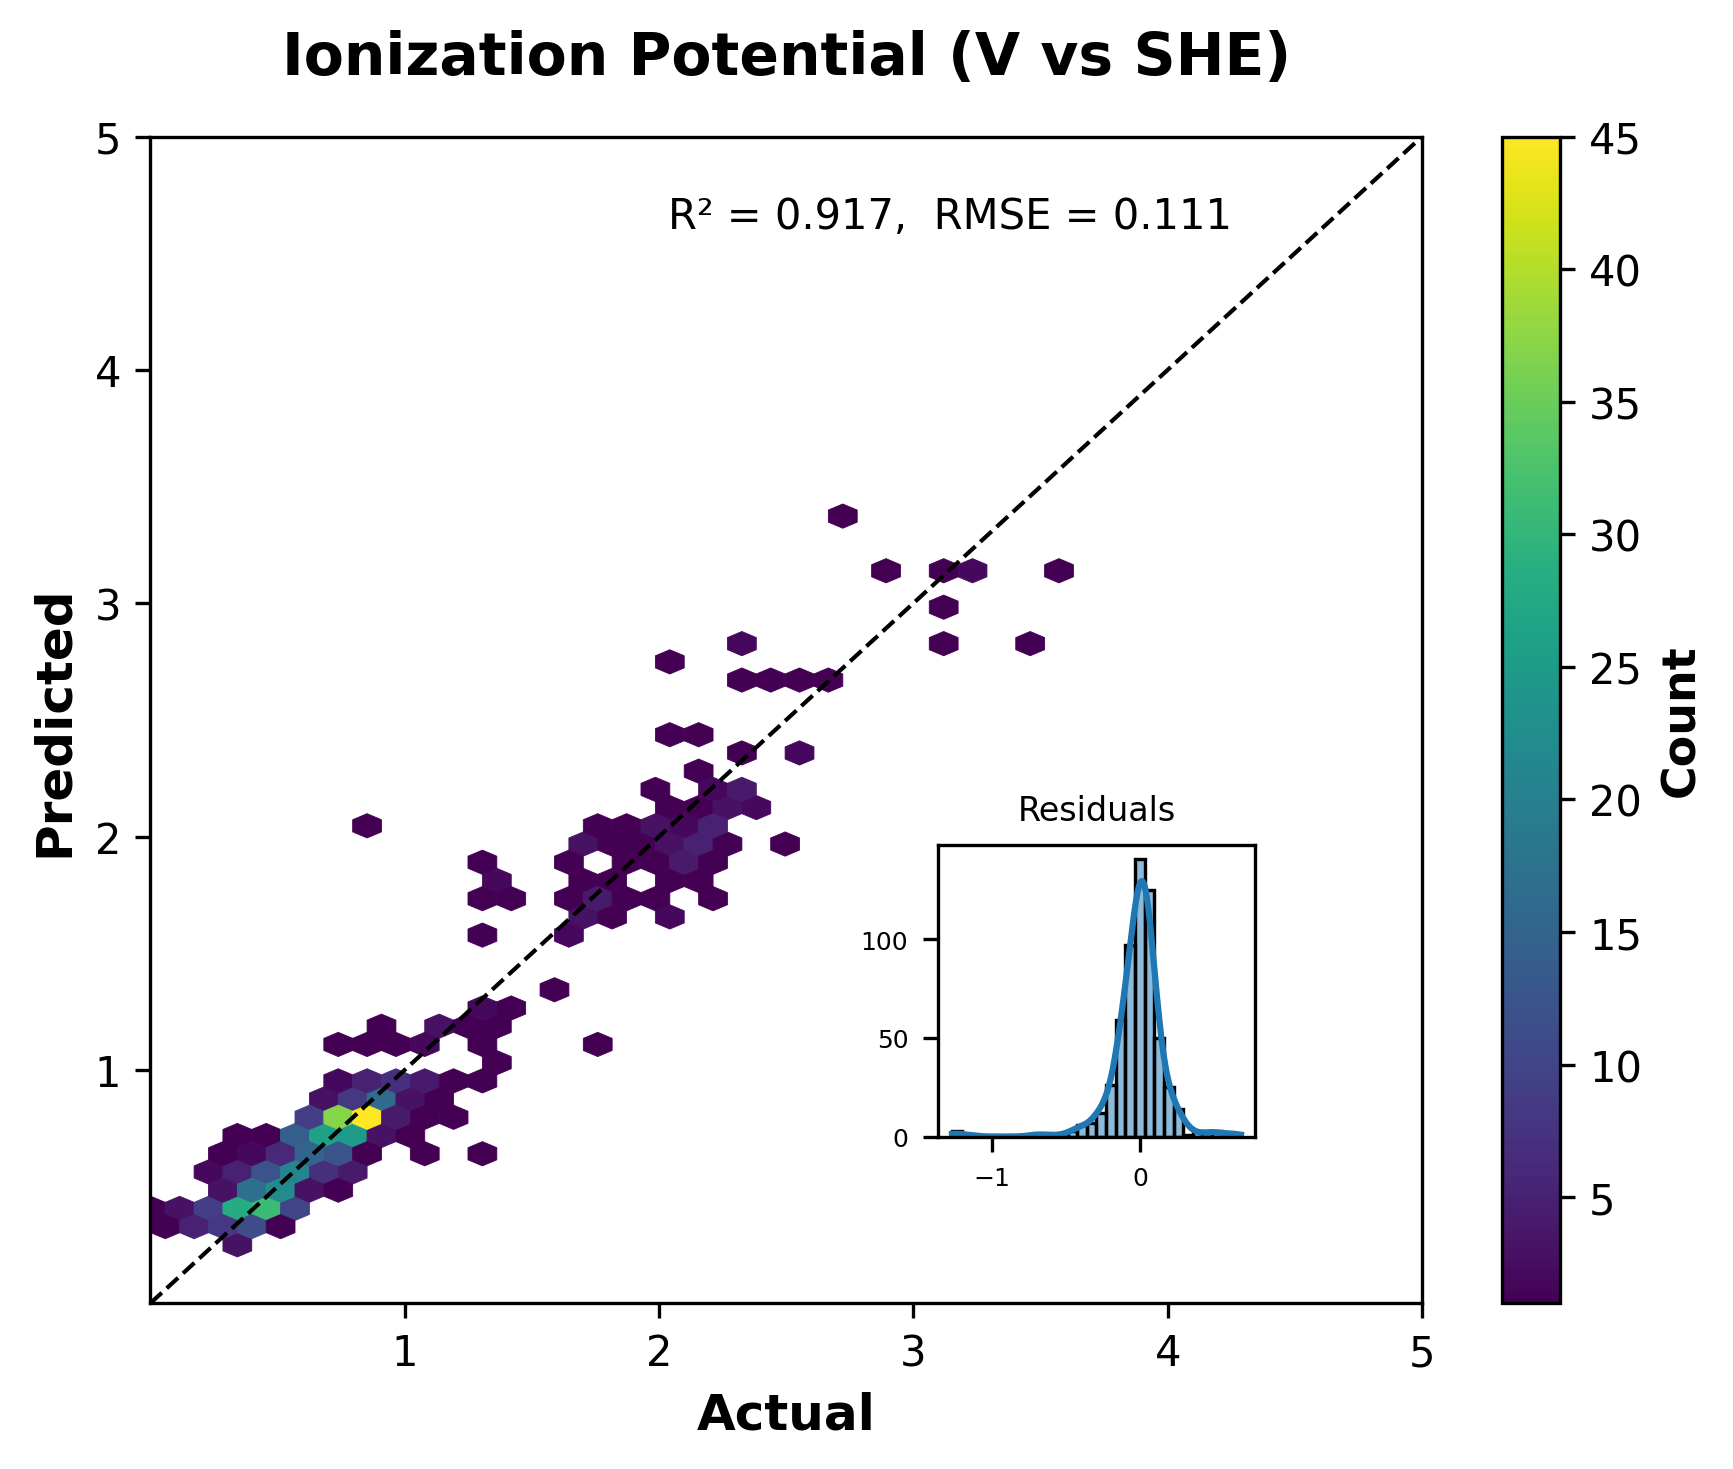

In [46]:
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Use point density plot (e.g. hexbin in matplotlib) instead of scatter plot for above to show the distribution information for the overlapped data points along with labeling the axes and adding a diagonal reference line.
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# Create hexbin plot with better visibility
hb = ax.hexbin(y_test_rand, y_pred_rand, gridsize=35, cmap='viridis', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Diagonal reference line
ax.plot([0, 5], [0, 5], 'k--', linewidth=1, color='black')
# ax.plot([y_test_rand.min(), y_test_rand.max()], [y_test_rand.min(), y_test_rand.max()], 'k--', linewidth=1, color='black')

# remove 0 tick mark from x and y axis
ax.set_xticks([tick for tick in ax.get_xticks() if tick != 0])
ax.set_yticks([tick for tick in ax.get_yticks() if tick != 0])

# adjust x and y axis range (max 5 - as original scatter plot)
# diagonal line -make sure it spans the whole plot range.
# ax.set_xlim(left=y_test_rand.min(), right=5)
# ax.set_ylim(bottom=y_test_rand.min(), top=5)
ax.set_xlim(left=0, right=5)
ax.set_ylim(bottom=0, top=5)

x_center = (y_test_rand.min() + y_test_rand.max()) / 2

# Title and axes labels
ax.set_title(f"Ionization Potential (V vs SHE)", 
             fontsize=14, fontweight='bold', pad=15)
# this should be inside the plot
y_top = ax.get_ylim()[1] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
ax.text(x_center + 1.5, y_top, f"R² = {stats_rand[0]:.3f},  RMSE = {stats_rand[1]:.3f}",
        fontsize=10, ha='center', va='top')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
# ➤ Inset residual plot
residuals = y_test_rand - y_pred_rand
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=4)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)
# ax.legend(fontsize=11, loc='upper left')
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("IP_hexbin_density_plot_rf_rand.png", dpi=300, bbox_inches='tight')
plt.show()